In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sales_data = pd.read_csv("../data/sales_transactions.csv")

In [4]:
sales_data.head()

,order_id,branch,item_name,quantity,price,revenue,order_date,order_hour,category,payment_method,day_of_week,is_weekend,meal_period,order_channel
0,1,Birmingham Selfridges,Dynamite Roll,4,6.5,26.0,2025-02-28,20,Sushi,Card,Friday,False,Dinner,Dine In
1,2,Manchester Selfridges,YO! Roll,3,6.0,18.0,2025-09-26,19,Sushi,Card,Friday,False,Dinner,Takeaway
2,3,Manchester Selfridges,YO! Roll,1,6.0,6.0,2025-09-27,13,Sushi,Card,Saturday,True,Lunch,Dine In
3,4,Leeds Selfridges,Chicken Katsu Curry,2,13.5,27.0,2025-04-11,19,Curry,Cash,Friday,False,Dinner,Uber Eats
4,5,London Selfridges,Salmon Dragon Roll,3,6.5,19.5,2025-04-16,13,Sushi,Card,Wednesday,False,Lunch,Takeaway


In [5]:
sales_data.shape

(10000, 14)

In [6]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  int64  
 1   branch          10000 non-null  object 
 2   item_name       10000 non-null  object 
 3   quantity        10000 non-null  int64  
 4   price           10000 non-null  float64
 5   revenue         10000 non-null  float64
 6   order_date      10000 non-null  object 
 7   order_hour      10000 non-null  int64  
 8   category        10000 non-null  object 
 9   payment_method  10000 non-null  object 
 10  day_of_week     10000 non-null  object 
 11  is_weekend      10000 non-null  bool   
 12  meal_period     10000 non-null  object 
 13  order_channel   10000 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(8)
memory usage: 1.0+ MB


In [7]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"])

sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10000 non-null  int64         
 1   branch          10000 non-null  object        
 2   item_name       10000 non-null  object        
 3   quantity        10000 non-null  int64         
 4   price           10000 non-null  float64       
 5   revenue         10000 non-null  float64       
 6   order_date      10000 non-null  datetime64[ns]
 7   order_hour      10000 non-null  int64         
 8   category        10000 non-null  object        
 9   payment_method  10000 non-null  object        
 10  day_of_week     10000 non-null  object        
 11  is_weekend      10000 non-null  bool          
 12  meal_period     10000 non-null  object        
 13  order_channel   10000 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(3), ob

In [12]:
sales_data.groupby("branch")["revenue"].sum().round(2).sort_values(ascending=False)

branch
Leeds Selfridges         47776.10
Manchester Selfridges    47027.90
London Selfridges        46328.25
Birmingham Selfridges    43265.80
Name: revenue, dtype: float64

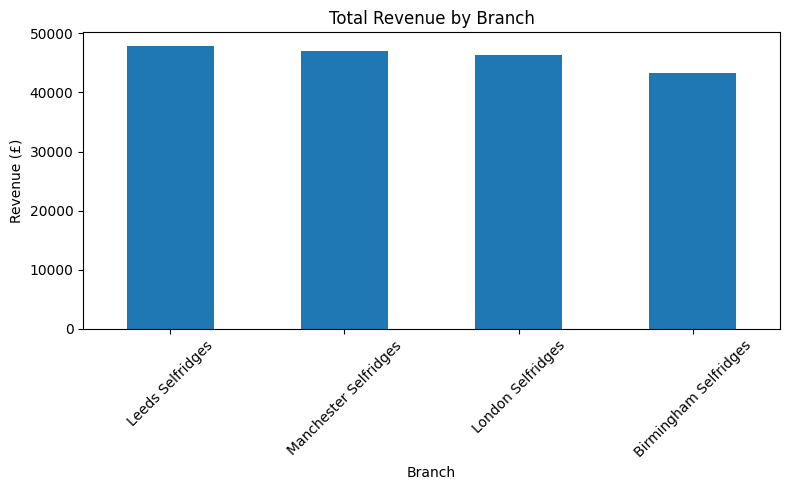

In [20]:
branch_revenue = (sales_data.groupby("branch")["revenue"]
                .sum()
                .round(2)
                .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
branch_revenue.plot(kind="bar")
plt.title("Total Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
category_revenue = (
    sales_data.groupby("category")["revenue"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print(category_revenue)

category
Sushi        38915.00
Curry        24374.00
Ramen        24316.50
Sides        22165.80
Dessert      19283.50
Hot Food     17913.60
Rice Bowl    13454.00
Drinks       12632.15
Alcohol      11343.50
Name: revenue, dtype: float64


In [22]:
category_quantity = (
    sales_data.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

category
Sushi        6680
Drinks       3410
Sides        3383
Dessert      3351
Hot Food     2298
Curry        1738
Alcohol      1684
Ramen        1677
Rice Bowl     868
Name: quantity, dtype: int64
